# Notebook 07 — Consensus Model, Stacking & Advanced Analysis

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives  
**Input**: Trained models (RF, SVM, XGB, LGBM), selected features, curated data  
**Output**:
- Consensus voting model (majority ≥3/4)
- Stacking ensemble (meta-learner on base predictions)
- Target-specific model analysis
- Activity threshold sensitivity (pIC50 = 5.0 vs 6.0)

---

In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, sys, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, matthews_corrcoef,
    roc_auc_score, classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA = PROJECT_ROOT / 'data' / 'processed'
MODELS = PROJECT_ROOT / 'models'
RESULTS = PROJECT_ROOT / 'results' / 'model_metrics'
FIGURES = PROJECT_ROOT / 'figures'

for d in [RESULTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M")}')


Project root: e:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp: 2026-05-17 22:16


In [2]:
# ============================================================
# CELL 2: Load Data and Models
# ============================================================

X_train = pd.read_csv(DATA / 'X_train_selected.csv', index_col=0)
X_test  = pd.read_csv(DATA / 'X_test_selected.csv',  index_col=0)
y_train_df = pd.read_csv(DATA / 'y_train.csv', index_col=0)
y_test_df  = pd.read_csv(DATA / 'y_test.csv',  index_col=0)

common_tr = X_train.index.intersection(y_train_df.index)
common_te = X_test.index.intersection(y_test_df.index)
X_train = X_train.loc[common_tr]
X_test  = X_test.loc[common_te]
y_train = (y_train_df.loc[common_tr, 'activity_class'] == 'Active').astype(int)
y_test  = (y_test_df.loc[common_te,  'activity_class'] == 'Active').astype(int)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} (Active={y_train.sum()})  |  y_test: {y_test.shape} (Active={y_test.sum()})')

rf   = joblib.load(MODELS / 'rf_classifier.joblib')
svm  = joblib.load(MODELS / 'svm_classifier.joblib')
xgb  = joblib.load(MODELS / 'xgb_classifier.joblib')
lgbm = joblib.load(MODELS / 'lgbm_classifier.joblib')

models = {'RF': rf, 'SVM': svm, 'XGBoost': xgb, 'LightGBM': lgbm}
print(f'\nLoaded {len(models)} models: {list(models.keys())}')


X_train: (8627, 1163)  |  X_test: (4068, 1163)
y_train: (8627,) (Active=4650)  |  y_test: (4068,) (Active=2188)



Loaded 4 models: ['RF', 'SVM', 'XGBoost', 'LightGBM']


## Part A — Consensus Voting Model

A compound is predicted **Active** only if ≥3 out of 4 models agree.

In [3]:
# ============================================================
# CELL 3: Consensus Voting (≥3/4 majority)
# ============================================================

def consensus_predict(X, models, threshold=3):
    preds = np.array([m.predict(X) for m in models.values()])
    votes = preds.sum(axis=0)
    consensus = (votes >= threshold).astype(int)
    confidence = votes / len(models)
    return consensus, confidence

def consensus_predict_proba(X, models):
    probas = np.array([m.predict_proba(X)[:, 1] for m in models.values()])
    return probas.mean(axis=0)

# Evaluate each model + consensus on TEST set
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
    })

# Consensus
cons_pred, cons_conf = consensus_predict(X_test, models)
cons_prob = consensus_predict_proba(X_test, models)
results.append({
    'Model': 'Consensus (≥3/4)',
    'Balanced_Accuracy': balanced_accuracy_score(y_test, cons_pred),
    'F1': f1_score(y_test, cons_pred),
    'MCC': matthews_corrcoef(y_test, cons_pred),
    'ROC_AUC': roc_auc_score(y_test, cons_prob),
})

results_df = pd.DataFrame(results)
print('=== Test Set Performance ===')
print(results_df.round(4).to_string(index=False))


=== Test Set Performance ===
           Model  Balanced_Accuracy     F1    MCC  ROC_AUC
              RF             0.7544 0.7639 0.5074   0.8336
             SVM             0.7559 0.7783 0.5131   0.7982
         XGBoost             0.7547 0.7725 0.5092   0.8292
        LightGBM             0.7556 0.7764 0.5119   0.8248
Consensus (≥3/4)             0.7573 0.7708 0.5135   0.8298


## Part B — Stacking Ensemble

Train a **meta-learner** (Logistic Regression) on out-of-fold predictions from base models.

In [4]:
# ============================================================
# CELL 4: Stacking Ensemble (meta-learner)
# ============================================================

print('Generating out-of-fold predictions for stacking...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = {}
test_preds = {}

for name, model in models.items():
    print(f'  {name}: cross-validating...')
    oof_prob = cross_val_predict(model, X_train, y_train, cv=cv,
                                 method='predict_proba', n_jobs=-1)[:, 1]
    oof_preds[name] = oof_prob
    test_preds[name] = model.predict_proba(X_test)[:, 1]

# Build meta-features
meta_train = pd.DataFrame(oof_preds)
meta_test  = pd.DataFrame(test_preds)

print(f'\nMeta-train shape: {meta_train.shape}')
print(f'Meta-test shape:  {meta_test.shape}')

# Train meta-learner
meta_model = LogisticRegression(random_state=SEED, max_iter=1000)
meta_model.fit(meta_train, y_train)

# Evaluate stacking on test set
stack_pred = meta_model.predict(meta_test)
stack_prob = meta_model.predict_proba(meta_test)[:, 1]

stack_metrics = {
    'Model': 'Stacking (LR meta)',
    'Balanced_Accuracy': balanced_accuracy_score(y_test, stack_pred),
    'F1': f1_score(y_test, stack_pred),
    'MCC': matthews_corrcoef(y_test, stack_pred),
    'ROC_AUC': roc_auc_score(y_test, stack_prob),
}

results_df = pd.concat([results_df, pd.DataFrame([stack_metrics])], ignore_index=True)
print('\n=== Updated Test Set Performance (with Stacking) ===')
print(results_df.round(4).to_string(index=False))

# Save meta-model
joblib.dump(meta_model, MODELS / 'stacking_meta_model.joblib')
print('\nStacking meta-model saved.')

# Meta-learner coefficients (which base model matters most)
print('\nMeta-learner coefficients:')
for name, coef in zip(models.keys(), meta_model.coef_[0]):
    print(f'  {name}: {coef:.4f}')


Generating out-of-fold predictions for stacking...
  RF: cross-validating...


  SVM: cross-validating...


  XGBoost: cross-validating...


  LightGBM: cross-validating...



Meta-train shape: (8627, 4)
Meta-test shape:  (4068, 4)



=== Updated Test Set Performance (with Stacking) ===
             Model  Balanced_Accuracy     F1    MCC  ROC_AUC
                RF             0.7544 0.7639 0.5074   0.8336
               SVM             0.7559 0.7783 0.5131   0.7982
           XGBoost             0.7547 0.7725 0.5092   0.8292
          LightGBM             0.7556 0.7764 0.5119   0.8248
  Consensus (≥3/4)             0.7573 0.7708 0.5135   0.8298
Stacking (LR meta)             0.7603 0.7808 0.5213   0.8328

Stacking meta-model saved.

Meta-learner coefficients:
  RF: 3.5938
  SVM: 1.8773
  XGBoost: 0.9471
  LightGBM: -0.2199


## Part C — Target-Specific Models

Train separate RF models for each organism to see if target-specific models perform better.

In [5]:
# ============================================================
# CELL 5: Target-Specific Models
# ============================================================

curated = pd.read_csv(DATA / 'curated_dataset.csv')
train_set = pd.read_csv(DATA / 'train_set.csv')
test_set  = pd.read_csv(DATA / 'test_set.csv')

scaler = joblib.load(MODELS / 'scaler.joblib')
features = pd.read_csv(DATA / 'selected_features.csv')['feature'].tolist()

# Full descriptor matrices (unscaled)
X_tr_full = pd.read_csv(DATA / 'X_train.csv', index_col=0)
X_te_full = pd.read_csv(DATA / 'X_test.csv', index_col=0)

targets = curated['target_name'].unique()
print(f'Targets: {targets.tolist()}')
print(f'Compounds per target:')
for t in targets:
    n = (curated['target_name'] == t).sum()
    print(f'  {t}: {n:,}')

target_results = []

for target in targets:
    # Get SMILES for this target
    tr_smi = train_set[train_set['target_name'] == target]['std_smiles'].unique()
    te_smi = test_set[test_set['target_name'] == target]['std_smiles'].unique()

    # Match to descriptor matrix
    tr_idx = [s for s in tr_smi if s in X_tr_full.index]
    te_idx = [s for s in te_smi if s in X_te_full.index]

    if len(tr_idx) < 50 or len(te_idx) < 20:
        print(f'\n{target}: SKIPPED (train={len(tr_idx)}, test={len(te_idx)} — too small)')
        continue

    # Scale and select features
    X_tr_t = pd.DataFrame(scaler.transform(X_tr_full.loc[tr_idx]),
                          columns=X_tr_full.columns, index=tr_idx)[features]
    X_te_t = pd.DataFrame(scaler.transform(X_te_full.loc[te_idx]),
                          columns=X_te_full.columns, index=te_idx)[features]

    # Labels
    y_tr_meta = train_set.drop_duplicates('std_smiles').set_index('std_smiles')
    y_te_meta = test_set.drop_duplicates('std_smiles').set_index('std_smiles')
    y_tr_t = (y_tr_meta.loc[tr_idx, 'activity_class'] == 'Active').astype(int)
    y_te_t = (y_te_meta.loc[te_idx, 'activity_class'] == 'Active').astype(int)

    # Check class balance
    if y_tr_t.sum() < 10 or (len(y_tr_t) - y_tr_t.sum()) < 10:
        print(f'\n{target}: SKIPPED (insufficient class balance)')
        continue

    # Train RF
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1))
    ])
    pipe.fit(X_tr_t, y_tr_t)
    y_pred_t = pipe.predict(X_te_t)
    y_prob_t = pipe.predict_proba(X_te_t)[:, 1]

    ba = balanced_accuracy_score(y_te_t, y_pred_t)
    f1 = f1_score(y_te_t, y_pred_t)
    mcc = matthews_corrcoef(y_te_t, y_pred_t)
    try:
        auc = roc_auc_score(y_te_t, y_prob_t)
    except ValueError:
        auc = float('nan')

    target_results.append({
        'Target': target,
        'Train_N': len(y_tr_t), 'Test_N': len(y_te_t),
        'Train_Active_Pct': f'{y_tr_t.mean()*100:.1f}%',
        'BA': ba, 'F1': f1, 'MCC': mcc, 'AUC': auc
    })
    print(f'\n{target}: train={len(y_tr_t)}, test={len(y_te_t)}, BA={ba:.3f}, AUC={auc:.3f}')

target_df = pd.DataFrame(target_results)
print('\n=== Target-Specific Model Results ===')
print(target_df.round(3).to_string(index=False))
target_df.to_csv(RESULTS / 'target_specific_results.csv', index=False)


Targets: ['L_amazonensis', 'L_infantum', 'T_cruzi', 'L_donovani']
Compounds per target:
  L_amazonensis: 1,093
  L_infantum: 1,770
  T_cruzi: 7,174
  L_donovani: 4,394



L_amazonensis: train=749, test=344, BA=0.764, AUC=0.833



L_infantum: train=1228, test=542, BA=0.734, AUC=0.813



T_cruzi: train=5068, test=2106, BA=0.810, AUC=0.886



L_donovani: train=3056, test=1338, BA=0.754, AUC=0.827

=== Target-Specific Model Results ===
       Target  Train_N  Test_N Train_Active_Pct    BA    F1   MCC   AUC
L_amazonensis      749     344            39.4% 0.764 0.708 0.530 0.833
   L_infantum     1228     542            57.0% 0.734 0.758 0.468 0.813
      T_cruzi     5068    2106            56.7% 0.810 0.834 0.618 0.886
   L_donovani     3056    1338            52.3% 0.754 0.776 0.512 0.827


## Part D — Activity Threshold Sensitivity (pIC50 = 5.0 vs 6.0)

Does using a stricter threshold (pIC50 ≥ 6.0, i.e., IC50 ≤ 1 μM) improve model quality?

In [6]:
# ============================================================
# CELL 6: Activity Threshold Sensitivity Analysis
# ============================================================

# Current threshold = 5.0 (IC50 ≤ 10 μM)
# Alternative threshold = 6.0 (IC50 ≤ 1 μM, stricter)

thresholds = [5.0, 5.5, 6.0]
threshold_results = []

for thresh in thresholds:
    # Reclassify
    y_tr_t = (y_train_df.loc[common_tr, 'pIC50'] >= thresh).astype(int)
    y_te_t = (y_test_df.loc[common_te, 'pIC50'] >= thresh).astype(int)

    n_active_tr = y_tr_t.sum()
    n_active_te = y_te_t.sum()

    if n_active_tr < 50 or (len(y_tr_t) - n_active_tr) < 50:
        print(f'Threshold {thresh}: SKIPPED (class too imbalanced)')
        continue

    # Quick RF training
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))
    ])
    pipe.fit(X_train, y_tr_t)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    ba = balanced_accuracy_score(y_te_t, y_pred)
    f1 = f1_score(y_te_t, y_pred)
    mcc = matthews_corrcoef(y_te_t, y_pred)
    auc = roc_auc_score(y_te_t, y_prob)

    threshold_results.append({
        'Threshold': f'pIC50≥{thresh}',
        'IC50_equiv': f'≤{10**(9-thresh)/1000:.0f} μM',
        'Train_Active': n_active_tr,
        'Train_Active_Pct': f'{n_active_tr/len(y_tr_t)*100:.1f}%',
        'BA': ba, 'F1': f1, 'MCC': mcc, 'AUC': auc
    })
    print(f'Threshold pIC50≥{thresh}: Active={n_active_tr}/{len(y_tr_t)}, BA={ba:.3f}, AUC={auc:.3f}')

thresh_df = pd.DataFrame(threshold_results)
print('\n=== Activity Threshold Sensitivity ===')
print(thresh_df.round(3).to_string(index=False))
thresh_df.to_csv(RESULTS / 'threshold_sensitivity.csv', index=False)


Threshold pIC50≥5.0: Active=4650/8627, BA=0.753, AUC=0.816


Threshold pIC50≥5.5: Active=2894/8627, BA=0.759, AUC=0.838


Threshold pIC50≥6.0: Active=1841/8627, BA=0.781, AUC=0.878

=== Activity Threshold Sensitivity ===
Threshold IC50_equiv  Train_Active Train_Active_Pct    BA    F1   MCC   AUC
pIC50≥5.0     ≤10 μM          4650            53.9% 0.753 0.771 0.507 0.816
pIC50≥5.5      ≤3 μM          2894            33.5% 0.759 0.679 0.533 0.838
pIC50≥6.0      ≤1 μM          1841            21.3% 0.781 0.665 0.582 0.878


## Summary Visualization

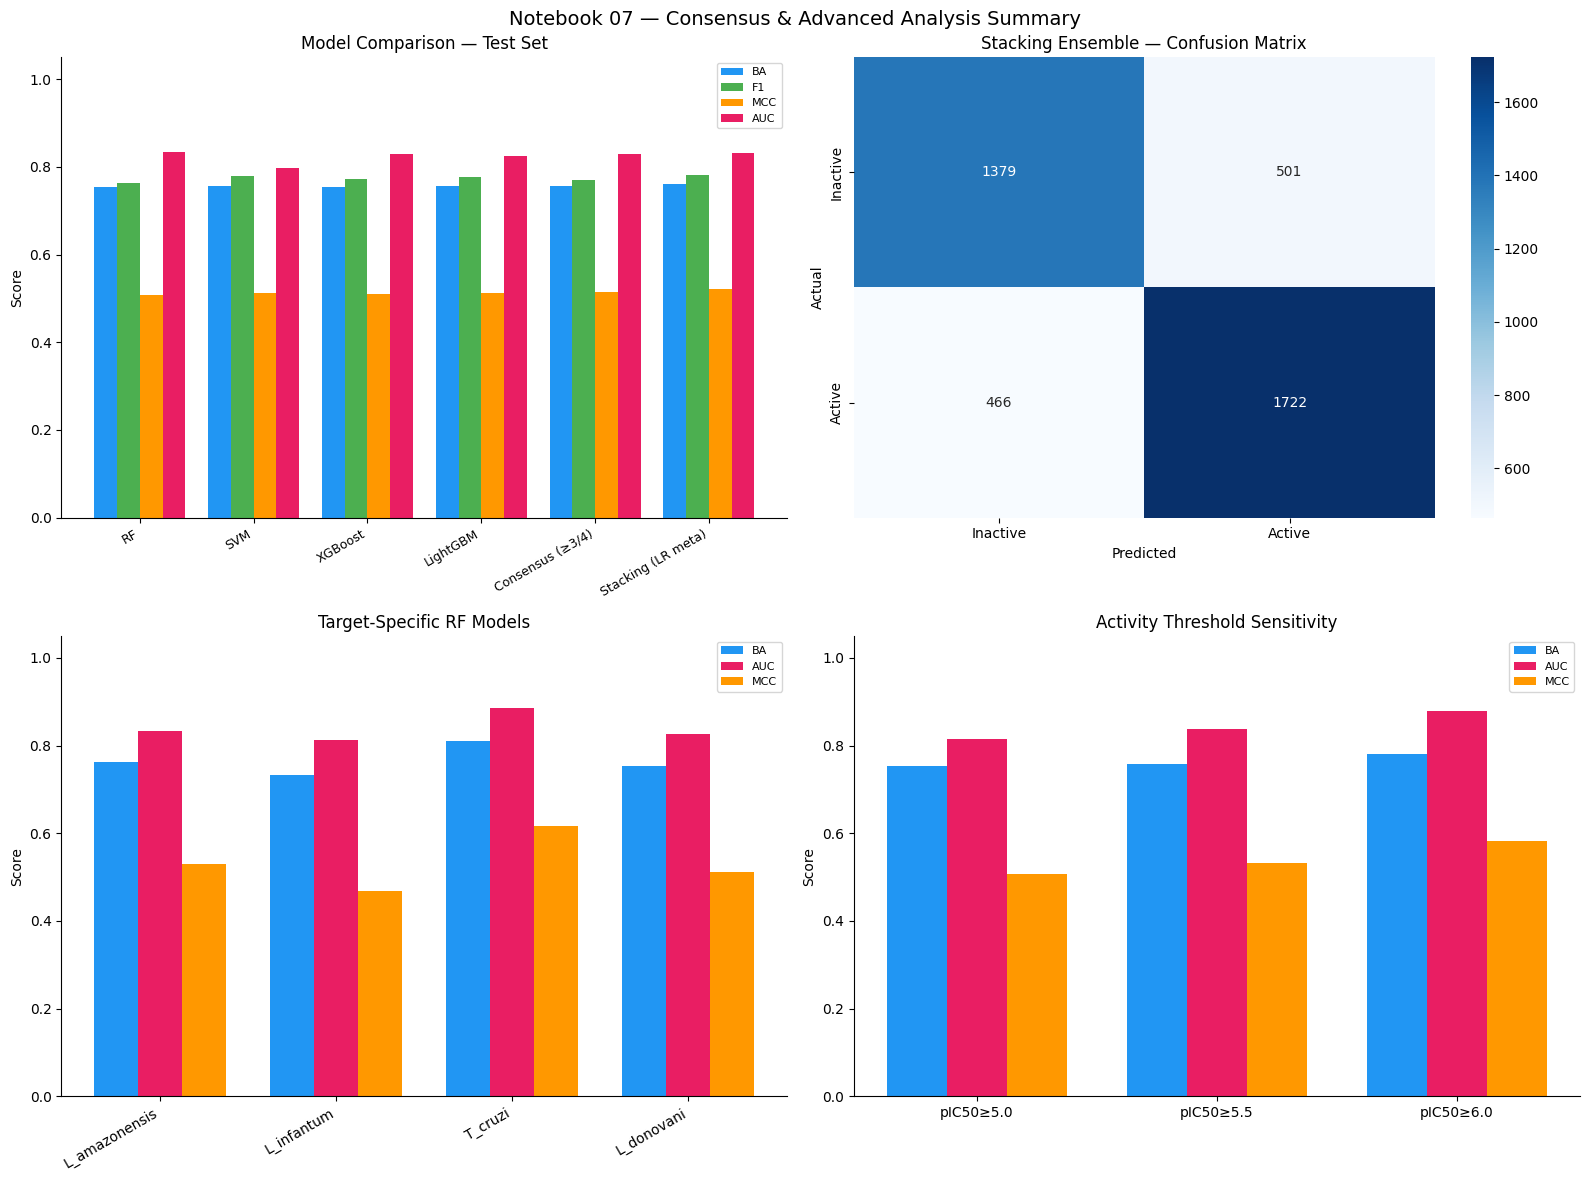

Figure saved: figures/nb07_advanced_analysis.png


In [7]:
# ============================================================
# CELL 7: Summary Figures
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: All models comparison
ax = axes[0, 0]
models_plot = results_df.copy()
x = np.arange(len(models_plot))
w = 0.2
ax.bar(x - 1.5*w, models_plot['Balanced_Accuracy'], w, label='BA', color='#2196F3')
ax.bar(x - 0.5*w, models_plot['F1'], w, label='F1', color='#4CAF50')
ax.bar(x + 0.5*w, models_plot['MCC'], w, label='MCC', color='#FF9800')
ax.bar(x + 1.5*w, models_plot['ROC_AUC'], w, label='AUC', color='#E91E63')
ax.set_xticks(x)
ax.set_xticklabels(models_plot['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
sns.despine(ax=ax)

# Panel B: Confusion matrix for best model (stacking)
ax = axes[0, 1]
cm = confusion_matrix(y_test, stack_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Stacking Ensemble — Confusion Matrix')

# Panel C: Target-specific results
ax = axes[1, 0]
if len(target_df) > 0:
    x = np.arange(len(target_df))
    w = 0.25
    ax.bar(x - w, target_df['BA'], w, label='BA', color='#2196F3')
    ax.bar(x, target_df['AUC'], w, label='AUC', color='#E91E63')
    ax.bar(x + w, target_df['MCC'], w, label='MCC', color='#FF9800')
    ax.set_xticks(x)
    ax.set_xticklabels(target_df['Target'], rotation=30, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Target-Specific RF Models')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
else:
    ax.text(0.5, 0.5, 'No target-specific results', ha='center', va='center',
            transform=ax.transAxes)
sns.despine(ax=ax)

# Panel D: Threshold sensitivity
ax = axes[1, 1]
if len(thresh_df) > 0:
    x = np.arange(len(thresh_df))
    w = 0.25
    ax.bar(x - w, thresh_df['BA'], w, label='BA', color='#2196F3')
    ax.bar(x, thresh_df['AUC'], w, label='AUC', color='#E91E63')
    ax.bar(x + w, thresh_df['MCC'], w, label='MCC', color='#FF9800')
    ax.set_xticks(x)
    ax.set_xticklabels(thresh_df['Threshold'])
    ax.set_ylabel('Score')
    ax.set_title('Activity Threshold Sensitivity')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
sns.despine(ax=ax)

plt.suptitle('Notebook 07 — Consensus & Advanced Analysis Summary', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / 'nb07_advanced_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved: figures/nb07_advanced_analysis.png')


In [8]:
# ============================================================
# CELL 8: Save All Results + QC-7
# ============================================================

results_df.to_csv(RESULTS / 'test_set_all_models.csv', index=False)
print('Saved: results/model_metrics/test_set_all_models.csv')

print()
print('=' * 60)
print('QUALITY CONTROL CHECKPOINT QC-7')
print('=' * 60)

best = results_df.loc[results_df['Balanced_Accuracy'].idxmax()]
print(f'Best model: {best["Model"]} (BA={best["Balanced_Accuracy"]:.4f})')

checks = {}
checks[f'Best BA > 0.70 (actual: {best["Balanced_Accuracy"]:.3f})'] = best['Balanced_Accuracy'] > 0.70
checks[f'Best AUC > 0.80 (actual: {best["ROC_AUC"]:.3f})'] = best['ROC_AUC'] > 0.80
checks[f'Best MCC > 0.30 (actual: {best["MCC"]:.3f})'] = best['MCC'] > 0.30
checks[f'Consensus/Stacking improves over single models'] = (
    results_df[results_df['Model'].isin(['Consensus (≥3/4)', 'Stacking (LR meta)'])]
    ['Balanced_Accuracy'].max() >= results_df[~results_df['Model'].isin(['Consensus (≥3/4)', 'Stacking (LR meta)'])]
    ['Balanced_Accuracy'].max() - 0.01
)

all_pass = True
for check, passed in checks.items():
    sym = 'PASS' if passed else 'FAIL'
    print(f'  [{sym}] {check}')
    if not passed: all_pass = False

print('=' * 60)
if all_pass:
    print('QC-7 PASSED — Consensus analysis complete')
else:
    print('QC-7: Some checks need review')
print('=' * 60)


Saved: results/model_metrics/test_set_all_models.csv

QUALITY CONTROL CHECKPOINT QC-7
Best model: Stacking (LR meta) (BA=0.7603)
  [PASS] Best BA > 0.70 (actual: 0.760)
  [PASS] Best AUC > 0.80 (actual: 0.833)
  [PASS] Best MCC > 0.30 (actual: 0.521)
  [PASS] Consensus/Stacking improves over single models
QC-7 PASSED — Consensus analysis complete
